<a href="https://colab.research.google.com/github/eojin22/ESAA/blob/main/16%EC%A3%BC%EC%B0%A8_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mall Customer Segmentation

Aim :
- To classify / cluster Mall Customers based on numerical and categorical features.
- It is an Unsupervised Learning problem statement.

Dataset Attributes:
- **CustomerID :** Unique ID assigned to the customer
- **Gender : **Gender of the customer
- **Age : **Age of the customer
- **Annual Income (k$) :** Annual Income of the customer
- **Spending Score (1-1000) :** Score assigned by the mall based on customer behavior and spending nature


Notebook Contents :
- Dataset Information
- Exploratory Data Analysis (EDA)
- Summary of EDA
- Feature Engineering
- Modeling
- Conclusion



## Dataset Information
**Import the Necessary Libraries :**

In [290]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [291]:
data = pd.read_csv('/content/Mall_Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Data Info :**

In [292]:
data.shape

(200, 5)

In [293]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [294]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


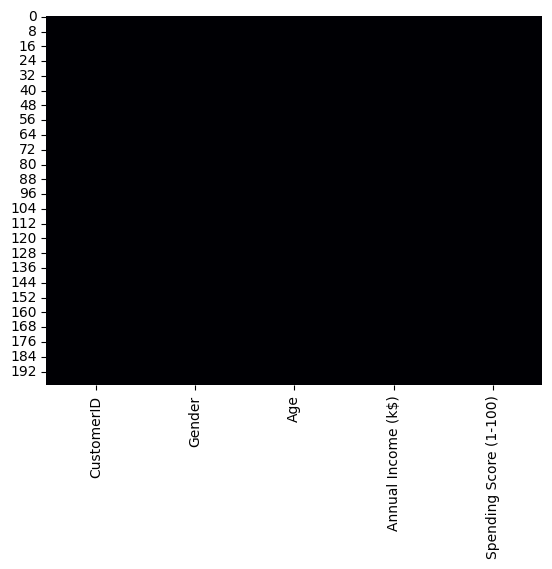

In [295]:
sns.heatmap(data.isnull(),cmap = 'magma',cbar = False);

- No null values present in the data

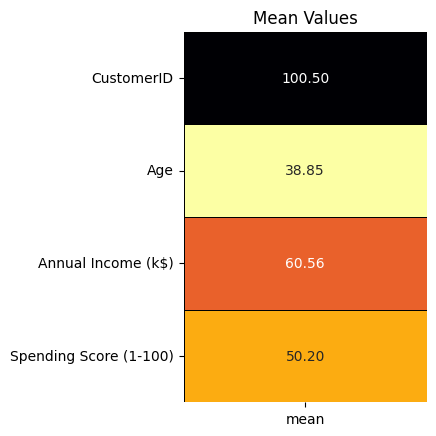

In [296]:
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))

plt.subplot(1,1,1)
sns.heatmap(data.describe().T[['mean']],cmap = 'inferno_r',annot = True,fmt = '.2f',linecolor = 'black',linewidths = 0.4,cbar = False);
plt.title('Mean Values');

fig.tight_layout(pad = 3)

- Average customer Age in the dataset is in the late 30s i.e 38.85.
- Average Annual Income (k$) of the customers is 60.56 i.e just short of the 2018 median income of USA citizen, 63k$.
- Spending Score (1-100) average of the mall customer is in the center with 50.20.

## Exploratory Data Analysis
**Dividing features into Numerical and Categorical :**

In [297]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : Gender
Numerical Features : CustomerID Age Annual Income (k$) Spending Score (1-100)


In [298]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep = True)

df1['Gender'] = le.fit_transform(df1['Gender'])

print('Label Encoder Transformation')
print(df1['Gender'].unique(),' = ',le.inverse_transform(df1['Gender'].unique()))

Label Encoder Transformation
[1 0]  =  ['Male' 'Female']


- 속성(attribute)의 고유값이 6개 미만이면 범주형, 6개 이상이면 수치으로 정의




In [299]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep=True)

df1['Gender'] = le.fit_transform(df1['Gender'])

print('Label Encoder Transformation')
print(df1['Gender'].unique(), ' = ',
      le.inverse_transform(df1['Gender'].unique()))

Label Encoder Transformation
[1 0]  =  ['Male' 'Female']


- Creating a deep copy of the orginal dataset and label encoding the text data of **Gender.**
- Modifications in the original dataset will not be highlighted in this deep copy.
- Hence, we use this deep copy of dataset that has Gender converted into numerical values for visualization & modeling purposes.


## Distribution of Categorical and Numerical Features :

/tmp/ipykernel_3073/2039315377.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
/tmp/ipykernel_3073/2039315377.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to 

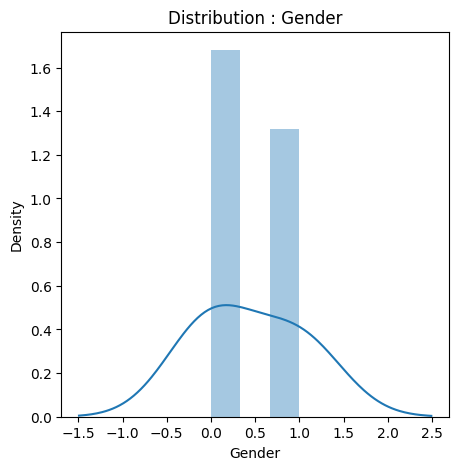

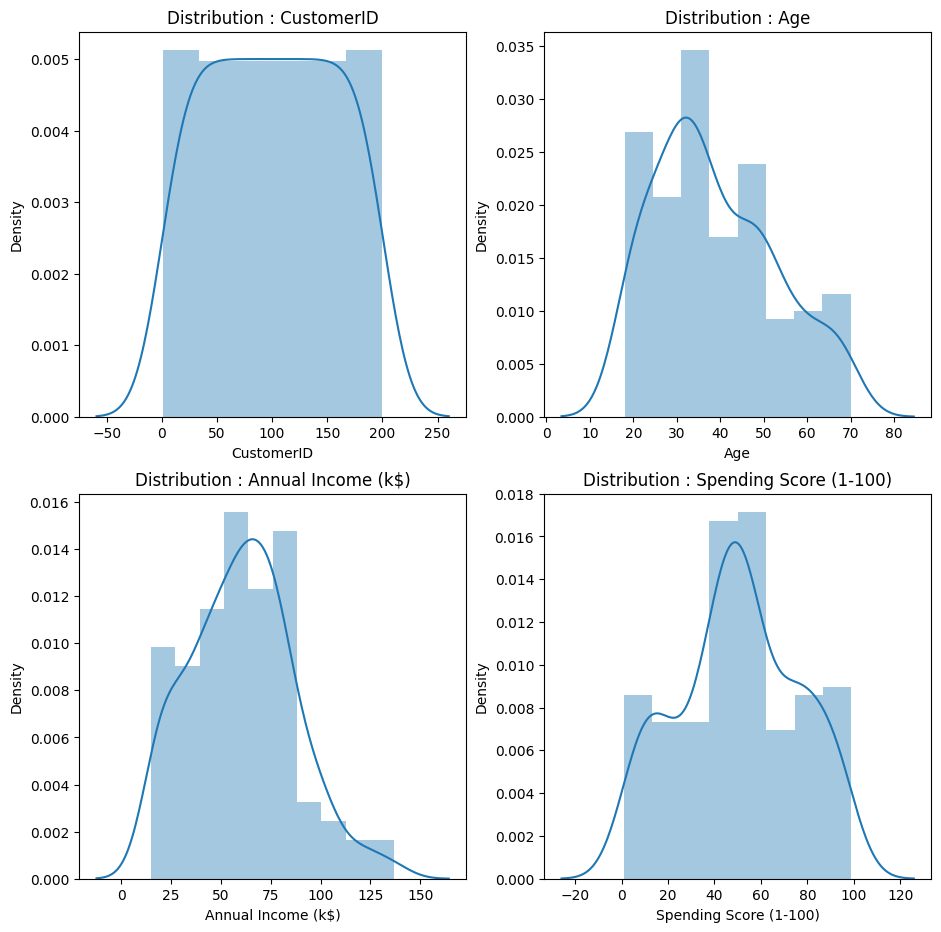

In [300]:
fig, ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))
for i in range(len(categorical_features)):
    plt.subplot(1,1,i+1)
    sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
    title = 'Distribution : ' + categorical_features[i]
    plt.title(title)

fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize = (11,11))
for i in range(len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.distplot(data[numerical_features[i]],)
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

- **Gender:** 유일한 범주형 특성이며, 데이터는 정규 분포를 나타냄.

- **Age 및 Annual Income :** 데이터 분포가 오른쪽으로 치우친 양의 왜도(Rightly skewed)를 보임.

- **Spending Score:** 주식 차트에서 볼 수 있는 헤드앤숄더(Head and Shoulder) 패턴과 유사한 분포를 나타냄. 이는 주가가 정점까지 상승했다가 이전의 상승 시작점까지 다시 하락하는 형태와 같음. 이와 유사하게 40~60 사이에 머리(Head)가 중심을 잡고, 20과 80 부근에서 두 어깨(Shoulder)가 형성되는 모양이 관찰됨.

- **CustomerID:** 단순히 고객에게 부여된 숫자에 불과하므로 해당 특성은 제외함.

In [301]:
numerical_features.remove('CustomerID')

## Categorical Features :

/tmp/ipykernel_3073/2571791004.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Gender', data = df1,palette = colors, edgecolor = 'black')
/tmp/ipykernel_3073/2571791004.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female', 'Male'])


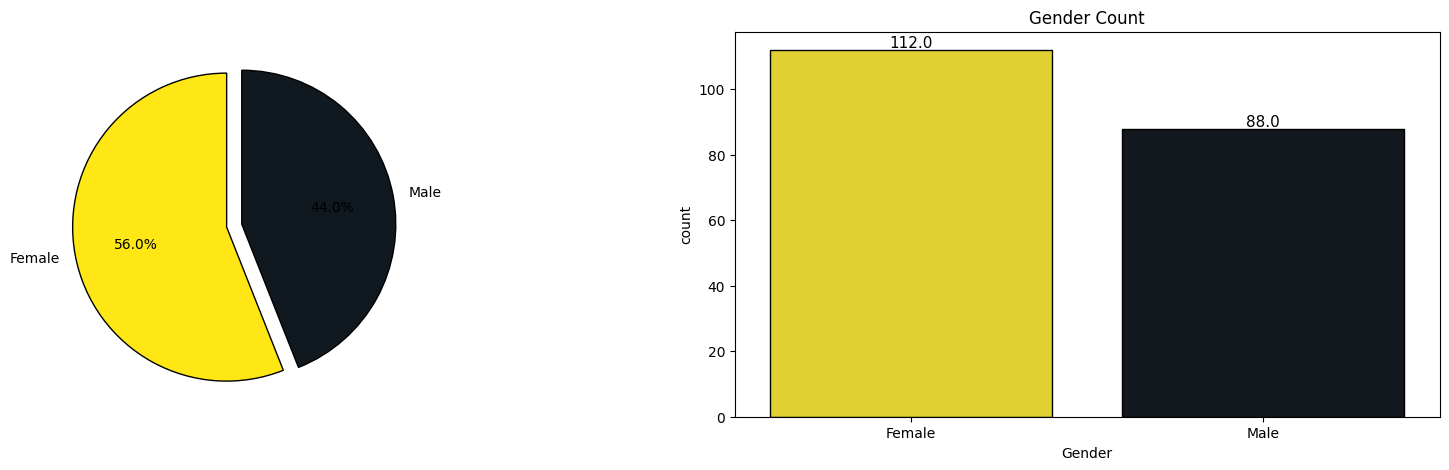

In [302]:
l = list(data['Gender'].value_counts())
circle = [l[0] / len(l) * 100, l[1] / len(l) * 100]
colors = ['#FEE715','#101820']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
plt.pie(circle,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),
        colors = colors, wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})

plt.subplot(1,2,2)
ax = sns.countplot(x='Gender', data = df1,palette = colors, edgecolor = 'black')
for rect in ax.patches:
  ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.75,
          rect.get_height(), horizontalalignment='center', fontsize=11)
plt.title('Gender Count')
ax.set_xticklabels(['Female', 'Male'])
plt.show()


## Numerical Features vs Categorical Features :

/tmp/ipykernel_3073/4190829715.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
/tmp/ipykernel_3073/4190829715.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female', 'Male'])
/tmp/ipykernel_3073/4190829715.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
/tmp/ipykernel_3073/4190829715.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels

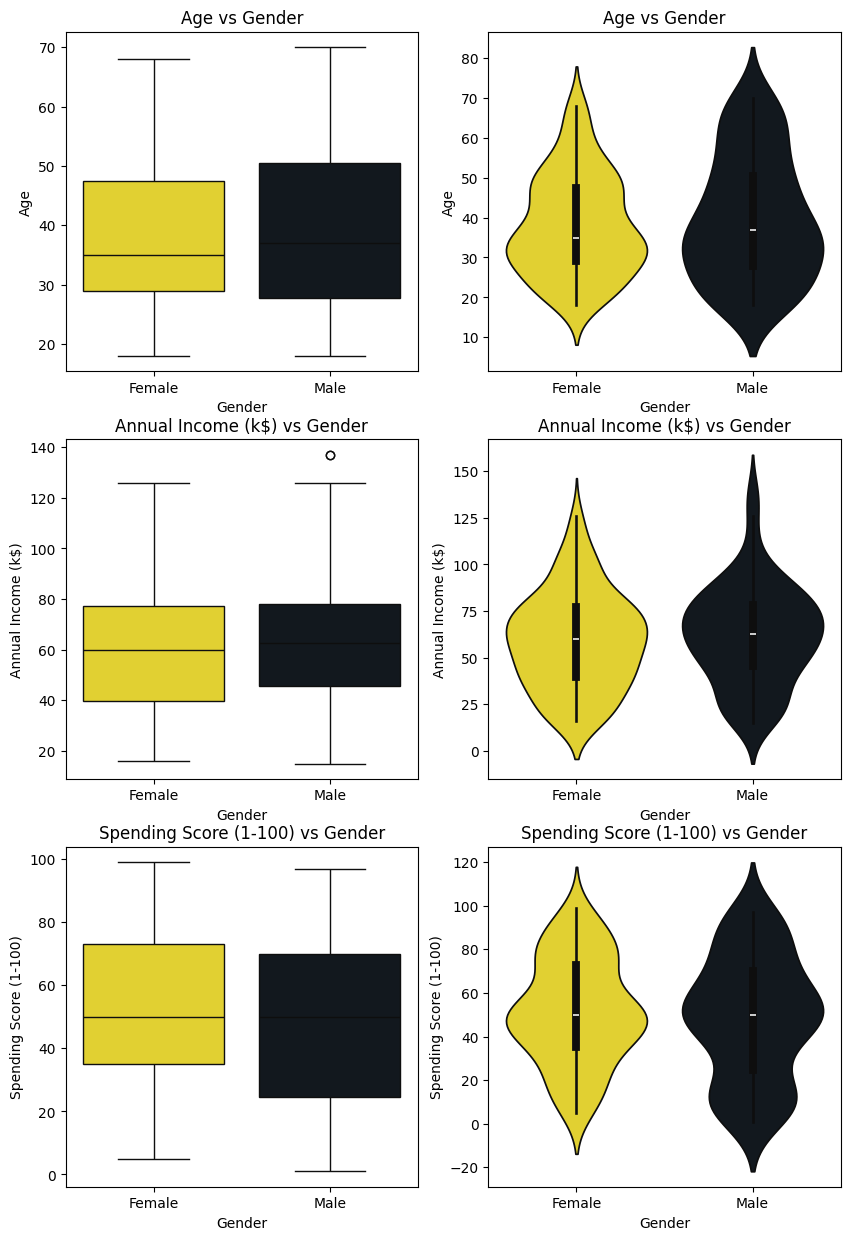

In [303]:
fig = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))
for i in range(len(numerical_features)):
  plt.subplot(3, 2, (i*2) + 1)
  ax = sns.boxplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
  ax.set_xticklabels(['Female', 'Male'])
  title = numerical_features[i] + ' vs Gender'
  plt.title(title)

  plt.subplot(3, 2, (i*2) + 2)
  ax = sns.violinplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
  ax.set_xticklabels(['Female', 'Male'])
  title = numerical_features[i] + ' vs Gender'
  plt.title(title)

- 여성 고객의 연령대는 30세부터 50세 직전까지인 반면, 남성 고객은 30세 직전부터 50세까지임.

- 남녀 모두 30~35세 구간에서 데이터가 부풀어 오르는(많이 몰리는) 현상이 관찰됨.

- 연령 중앙값(Median Age)은 남성이 여성보다 약간 더 높음.

- 여성 고객의 소득은 40k부터 시작하는 반면, 남성 고객의 소득은 이보다 높은 지점부터 시작함.

- 남녀 모두 연간 소득의 중앙값은 60k 근처임.

- 남성 고객의 연간 소득은 최고점 부근에서 여성 고객에 비해 매우 급격히 줄어들며, 일부 이상치(Outliers)가 존재함.

- 시작점의 경우 여성 고객은 40 직전, 남성 고객은 20 직후로 서로 다르지만, 소비 지수 중앙값은 남녀가 동일함.

- 남녀 모두 중앙값 부근에서 강력하게 데이터가 몰리는 경향을 보이며, 특히 여성 고객에게서 이러한 현상이 두드러짐.다만, 남성 고객의 경우 0~20 구간에서도 작지만 의미 있는 수준으로 데이터가 몰리는 현상이 관찰됨.

## Numerical Features vs Numerical Features w.r.t Categorical Feature

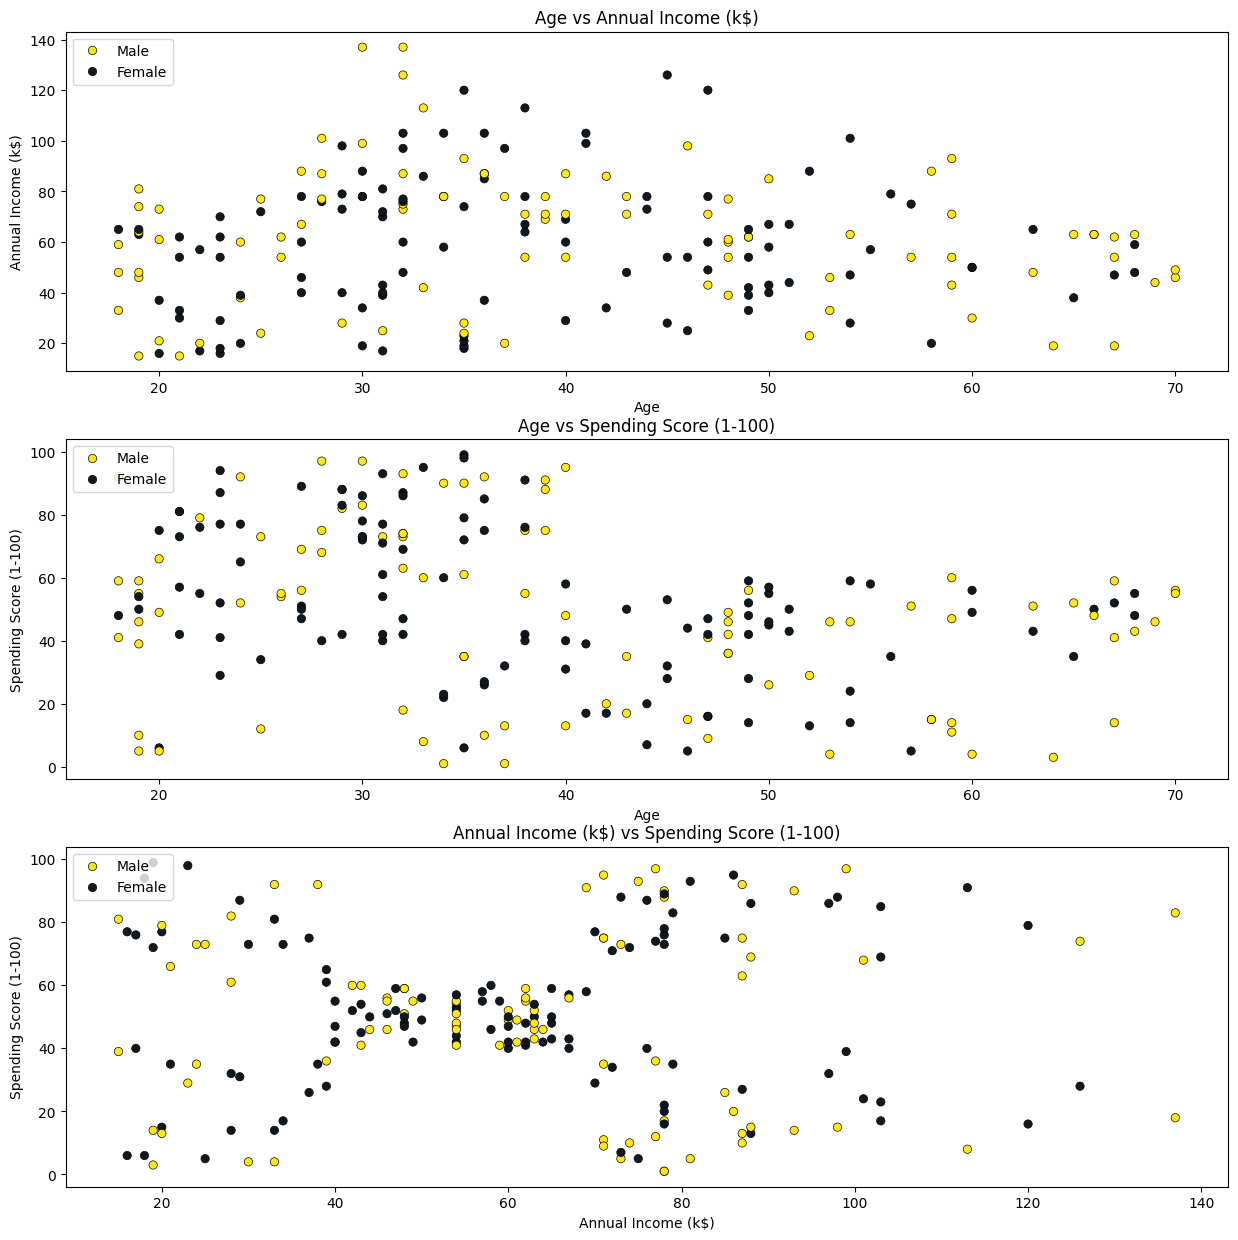

In [304]:
a = 0
fig,ax = plt.subplots(nrows = 3,ncols = 1,figsize = (15,15))
for i in range(len(numerical_features) - 1):
    for j in range(len(numerical_features)):
        if i != j and j > i:
            a += 1
            plt.subplot(3,1,a)
            sns.scatterplot(x = numerical_features[i],y = numerical_features[j],data = data,
                            hue = 'Gender',palette = colors,edgecolor = 'black');
            plt.legend(loc = 'upper left',)
            title = numerical_features[i] + ' vs ' + numerical_features[j]
            plt.title(title)

- Annual Income는 모든 연령대에 걸쳐 고르게 존재하며, Gender은 소득 분포에 유의미한 정보를 제공하지 않음(성별에 따른 차이가 크지 않음).

- Spending Score (1–100) 기준으로는 20~30세 연령대에서 매우 높은 소비 성향이 뚜렷하게 관찰됨.
- 30~40세 연령대에서는 소비 성향이 매우 높거나 매우 낮은 양극단의 특징이 모두 두드러짐.
- 40~70세 연령대 고객은 소비 지수가 낮은 반대편 극단의 소비 성향을 나타냄.
- Annual Income와 Spending Score (1–100)의 관계에서는 명확하게 구분되는 5개의 고객 그룹이 관찰됨.

- 낮은 소득 군 (0- 40k): 소비 지수가 0- 40인 그룹과 60- 100인 그룹으로, 총 2개의 고객 그룹이 뚜렷하게 나타남.
- 중간 소득 군 (40 -70k): 위의 양극단 분포를 지나면, 연간 소득 40-70k 및 소비 지수 40-60 사이의 중간 지점에 몰려 있는 고객 그룹이 부각됨.
- 높은 소득 군 (70 - 140k): 나머지 반대편 극단 영역으로, 소비 지수 기준 0- 40구간과 60-100 구간으로 나뉘는 2개의 고객 그룹이 정의됨.

## Summary of EDA

**성별(Gender)**
- 여성 고객의 수가 남성 고객보다 더 많음.
- 다만, 성별 데이터는 다른 특성(변수)들과 비교했을 때 전반적으로 꽤 균등하게 분포되어 있음.

**연령대(Age Groups)**
- 쇼핑몰 고객은 크게 20-30세, 30-40세, 40-70세의 3개 연령 그룹으로 나눌 수 있음.

**연간 소득(Annual Income (k$))**
- 남녀 모두 연간 소득의 중앙값은 약 60k 수준
- 소득 수치는 0-40k, 40-70k, 70-140k의 3개 그룹으로 분류됨.

**소비 지수(Spending Score (1-100))**
- 여성 고객의 소비 지수가 남성 고객보다 더 높게 나타남.
- 소비 지수를 기준으로도 고객을 0-40, 40-60, 60-100의 3개 그룹으로 나눌 수 있음.



## Feature Engineering
**Correlation Matrix :**

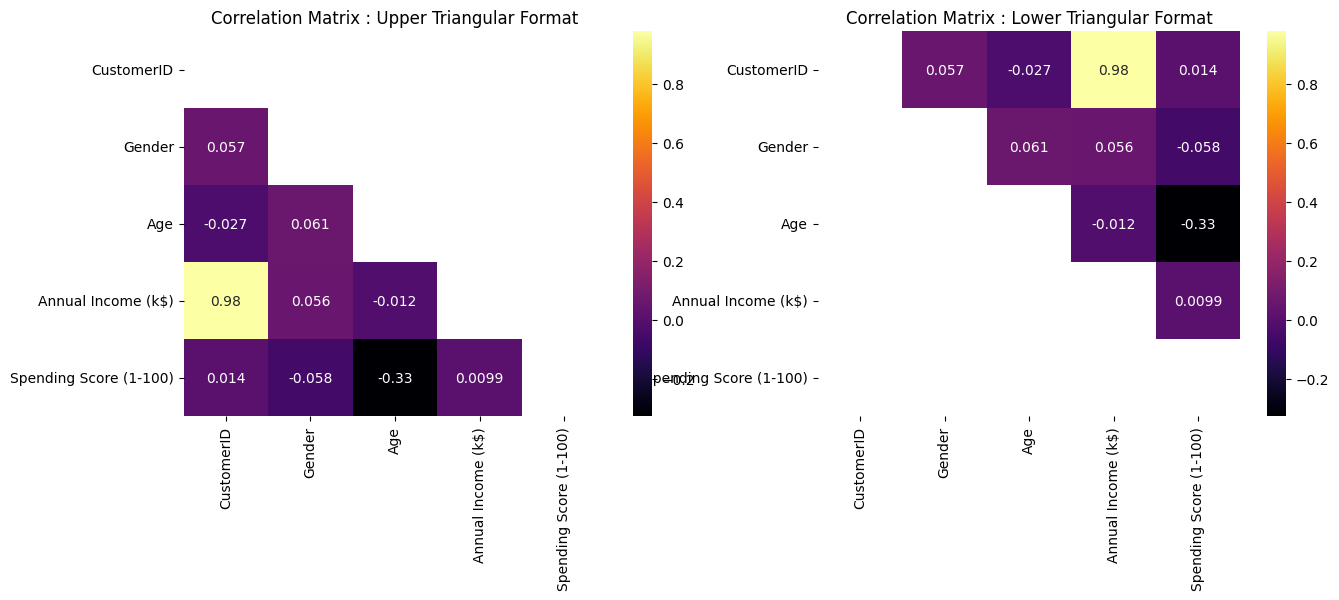

In [305]:
ut = np.triu(df1.corr())
lt = np.tril(df1.corr())

fig,ax = plt.subplots(nrows = 1, ncols = 2,figsize = (15,5))
plt.subplot(1,2,1)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = ut);
plt.title('Correlation Matrix : Upper Triangular Format');

plt.subplot(1,2,2)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = lt);
plt.title('Correlation Matrix : Lower Triangular Format');

df1.drop(columns = 'CustomerID',inplace = True)

- 제시된 두 행렬은 동일한 원본 데이터이며, 오직 시각적 가시성을 높이기 위해 중복 배치한 것임. 이 방식은 데이터셋의 특성(Feature) 수가 너무 많아 한눈에 파악하기 힘들 때 유용하게 활용할 수 있는 기법
- 고객 식별 번호(CustomerID) : 데이터셋이 연간 소득 기준 오름차순으로 정렬되어 있어, CustomerID와 연간 소득(Annual Income (k$)) 간에 매우 높은 양의 상관관계가 나타남. 그러나 단순 정렬에 의한 결과이므로 모델링 과정에서는 CustomerID를 제외할 예정
- 성별(Gender): 타 특성들과의 상관계수가 0에 가깝게 수렴하며, 다른 변수들과 어떠한 유의미한 연관성도 보이지 않는 중립적인 상태
- 소비 지수(Spending Score)와 연령(Age)의 관계: 두 변수 간에는 명확한 음의 상관관계가 존재함. 즉, 한 특성의 값이 증가하면 다른 특성의 값은 감소하고, 반대의 경우도 동일하게 성립함.
- 이후에는 다양한 변수 조합을 활용하여 고객 세분화(Segmentation) 모델링을 수행하고 고객군을 구분할 예정임.

## Data Scaling :
- 본 데이터셋에서는 연령(Age), 연간 소득(Annual Income (k$)), 소비 지수(Spending Score (1-100))의 3가지 특성에 대해 정규화를 수행함. 성별(Gender) 특성은 변경 없이 그대로 유지함.

In [306]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

# Label Encoding
df2 = df1.copy(deep=True)

# Normalization
df2['Age'] = mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)'] = mms.fit_transform(df2[['Annual Income (k$)']])
df2['Spending Score (1-100)'] = mms.fit_transform(df2[['Spending Score (1-100)']])

## Modeling

**비지도 학습(Unsupervised Learning)**
- 타깃 변수(정답 레이블)가 알려지지 않은 상태에서 학습하는 데이터 분석. 여러 수치를 측정하지만 기저의 질병명을 알지 못하는 의료 영역 등에서 광범위하게 발생함.
- 표 형태의 수치 데이터만으로는 파악하기 어려운 내재된 통찰을 얻기 위해 시각화 기법을 활용해 패턴을 찾아야 함. 그러나 데이터셋이 너무 크고 특성(Feature)이 많아지면 데이터 시각화 작업 자체가 매우 번거롭고 실행하기 어려워짐.

**K-평균 군집화(K-Means Clustering)**
- 범주형 특성을 지원하지 않으며, 비지도 학습 문제를 해결할 때 가장 선호되는 수학적 접근 방식의 군집화 알고리즘
- 작동 원리:
 1. 임의로 중심점(Centroid)을 선택함 (예: $k = 2$이면 2개의 중심점 선택).
 2. 선택한 중심점들과 모든 데이터 포인트 사이의 거리를 계산
 3. 각 데이터 포인트는 자신과 더 가까운 중심점의 레이블로 할당됨.
 4. 형성된 군집별로 속해 있는 데이터 포인트들의 평균값을 계산하고, 이 평균값을 새로운 중심점으로 정의
 5. 두 중심점이 특정 고정된 점으로 수렴(더 이상 변하지 않음)할 때까지 이 과정을 반복

**k hyperparameter**
- k = 클러스터 개수
- 최적의 k를 찾기 위해 두 가지 방법을 사용
1. Elbow Method
- k 값에 따른 오차 제곱합(SSE)을 그래프로 그림. 그래프가 팔꿈치 모양으로 꺾이는 지점의 k를 선택.
2. Silhouette Score
- 데이터 포인트가 얼마나 잘 뭉쳐 있는지 평가.
- 거리 공식을 기반으로 계산되며, 점수가 가장 높게 나타나는 $k$ 값을 모델링용 최적값으로 선택함.

In [307]:
# Dropping categorical feature
df1.drop(columns = 'Gender',inplace = True)
df2.drop(columns = 'Gender',inplace = True)

### Age - Annual Income (k$)

In [308]:
m1 = df1[['Age','Annual Income (k$)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)']].values # Normalized Dataset

### Original Dataset :
**Elbow Method & Silhouette Score Method :**

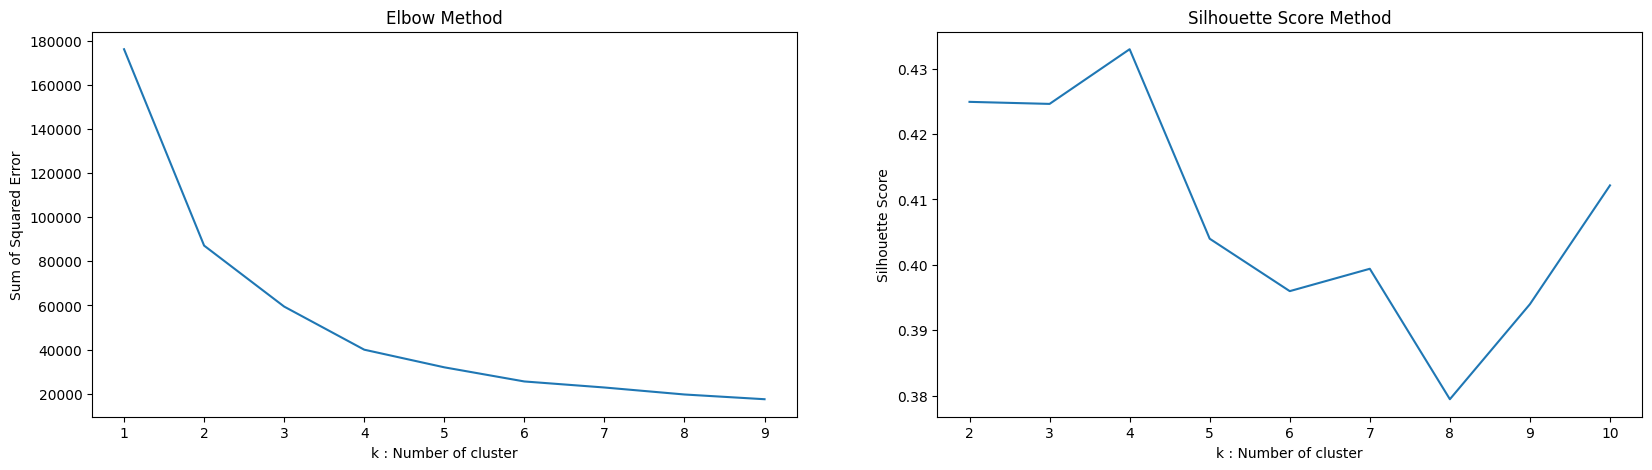

In [309]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- k : Clusters = 4

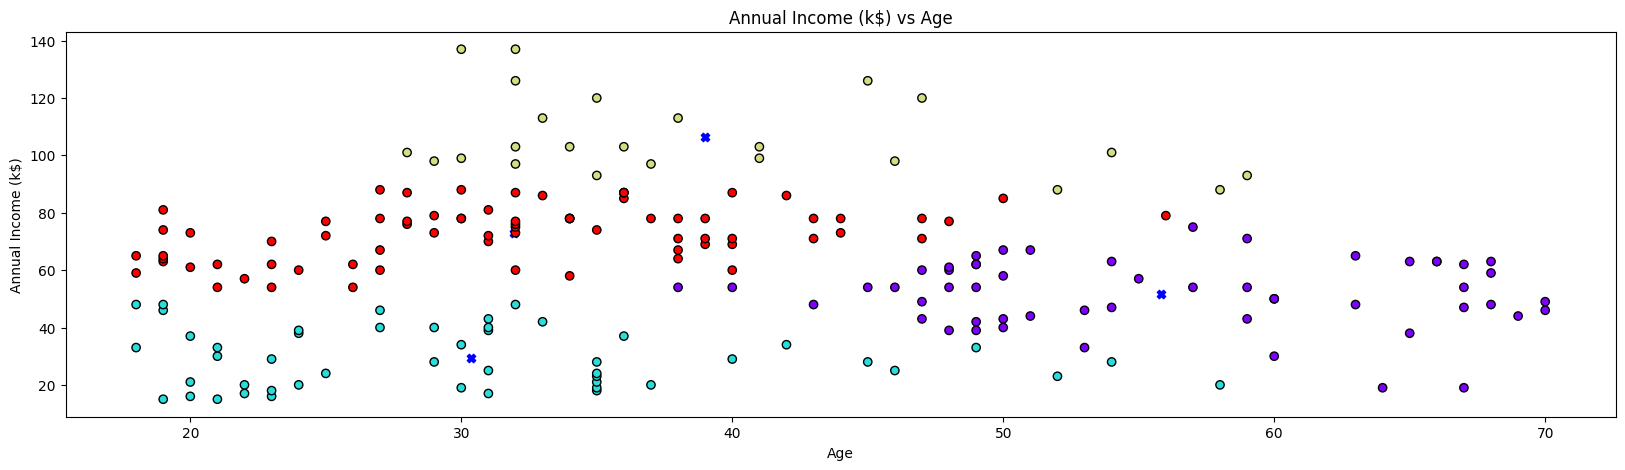

In [310]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

## Normalized Dataset :
**Elbow Method & Silhouette Score Method :**

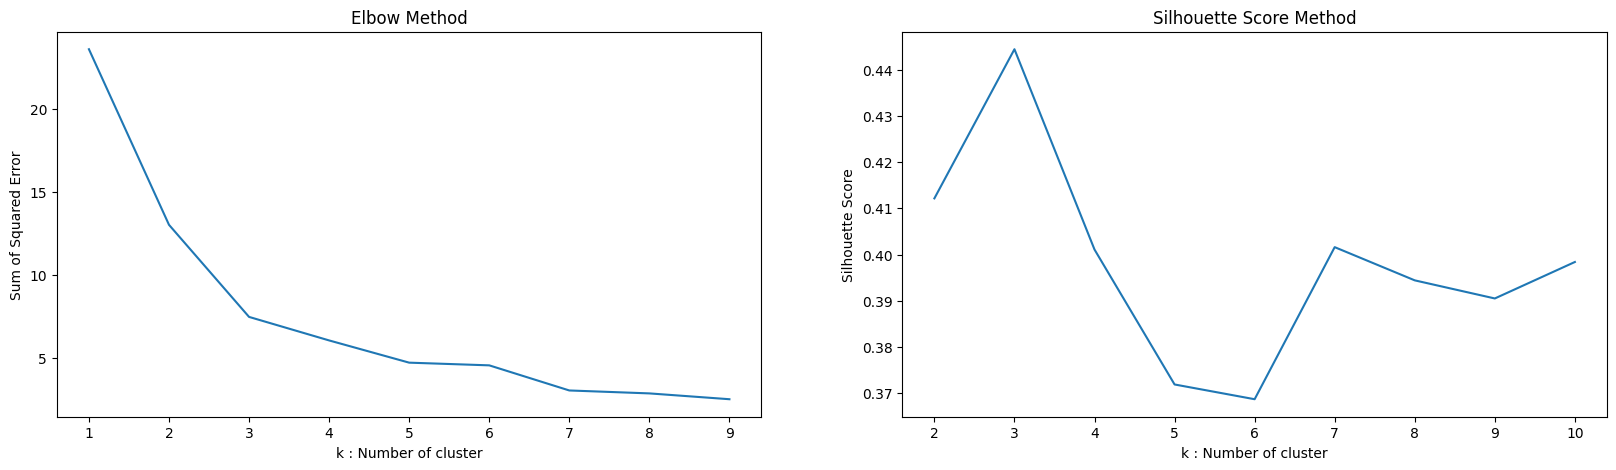

In [311]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- k : Clusters = 3

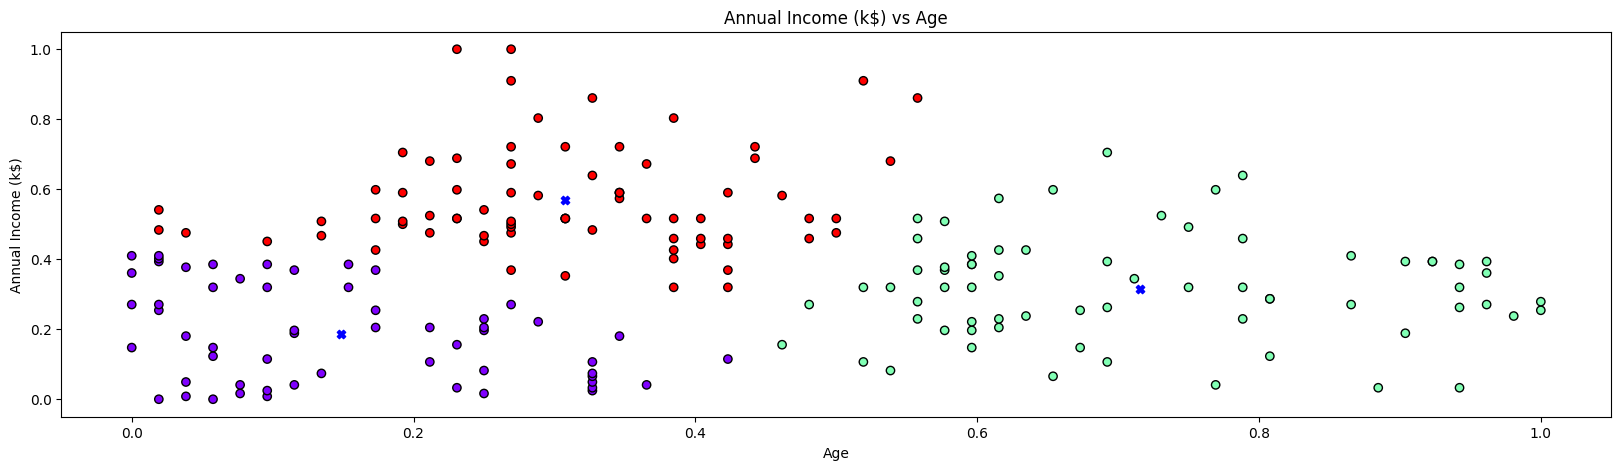

In [312]:
model = KMeans(n_clusters = 3,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

### Age - Spending Score (1-100)

In [313]:
m1 = df1[['Age','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Spending Score (1-100)']].values # Normalized Dataset

### Original Dataset :
**Elbow Method & Silhouette Score Method :**

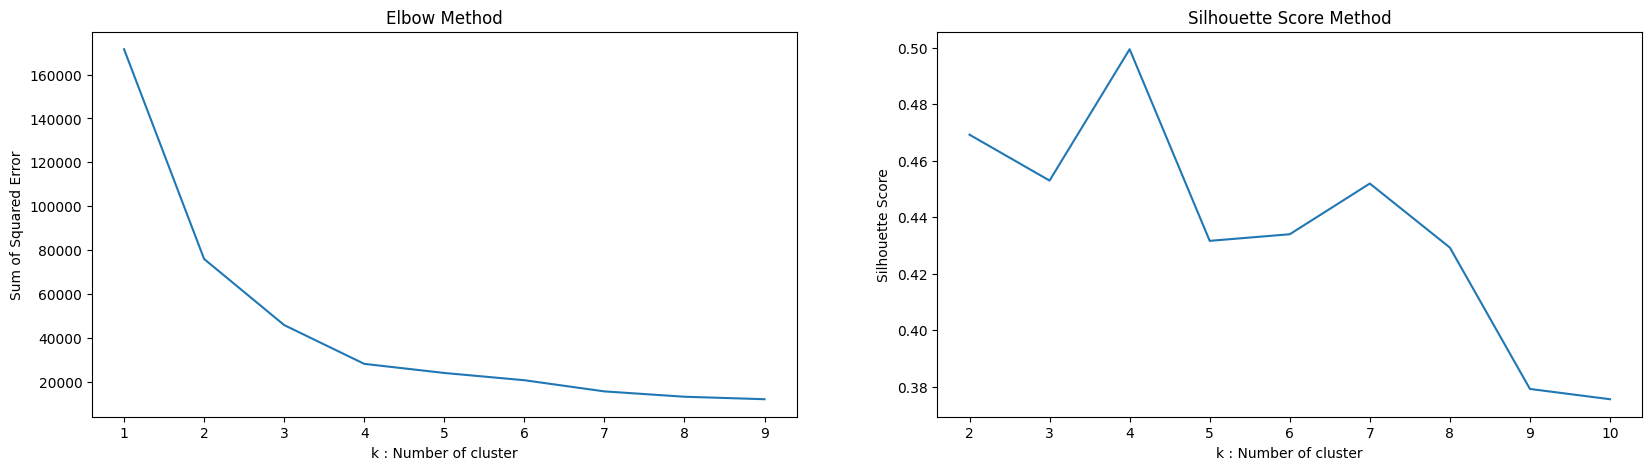

In [314]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- k : Clusters = 4

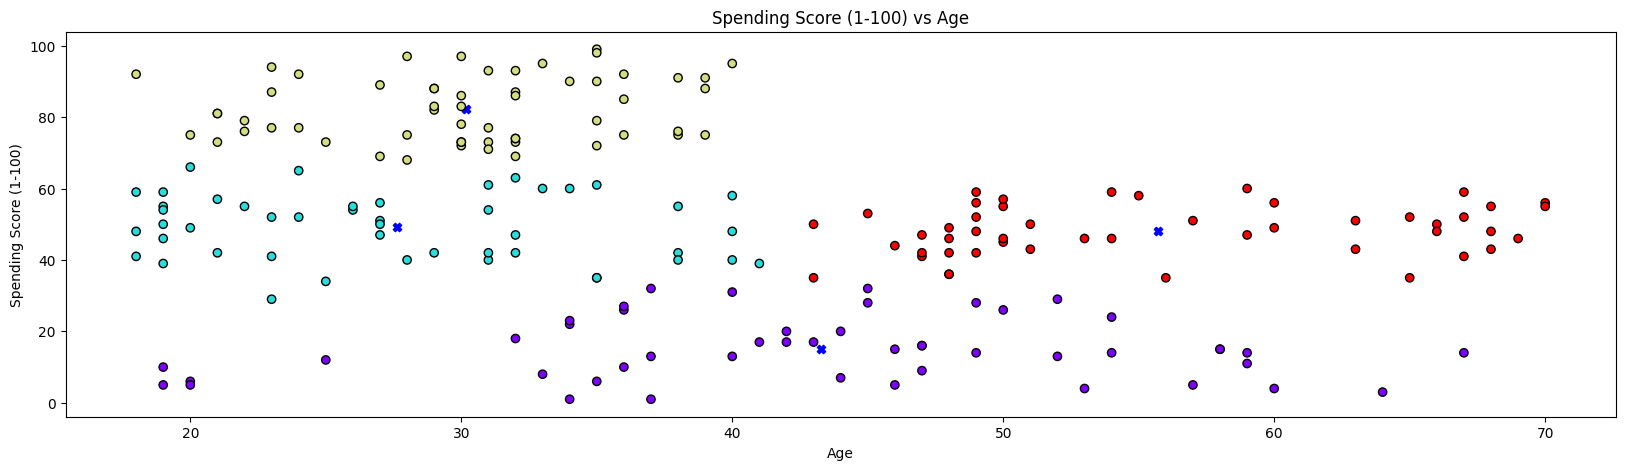

In [315]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Normalized Dataset :
**Elbow Method & Silhouette Score Method :**

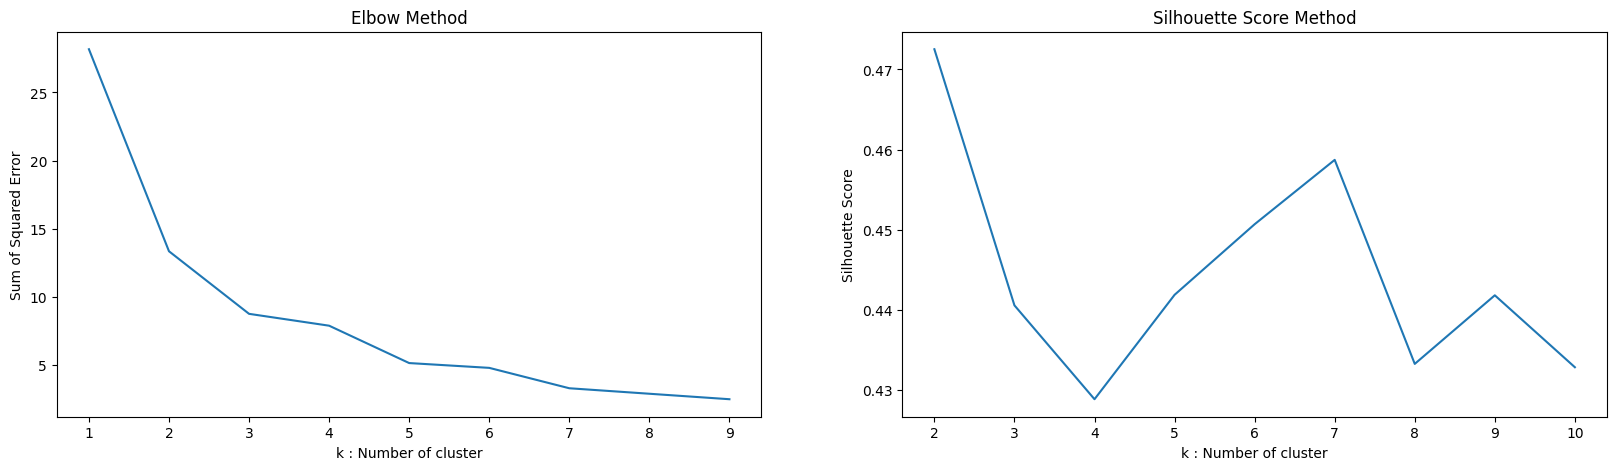

In [316]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- k : Clusters = 6

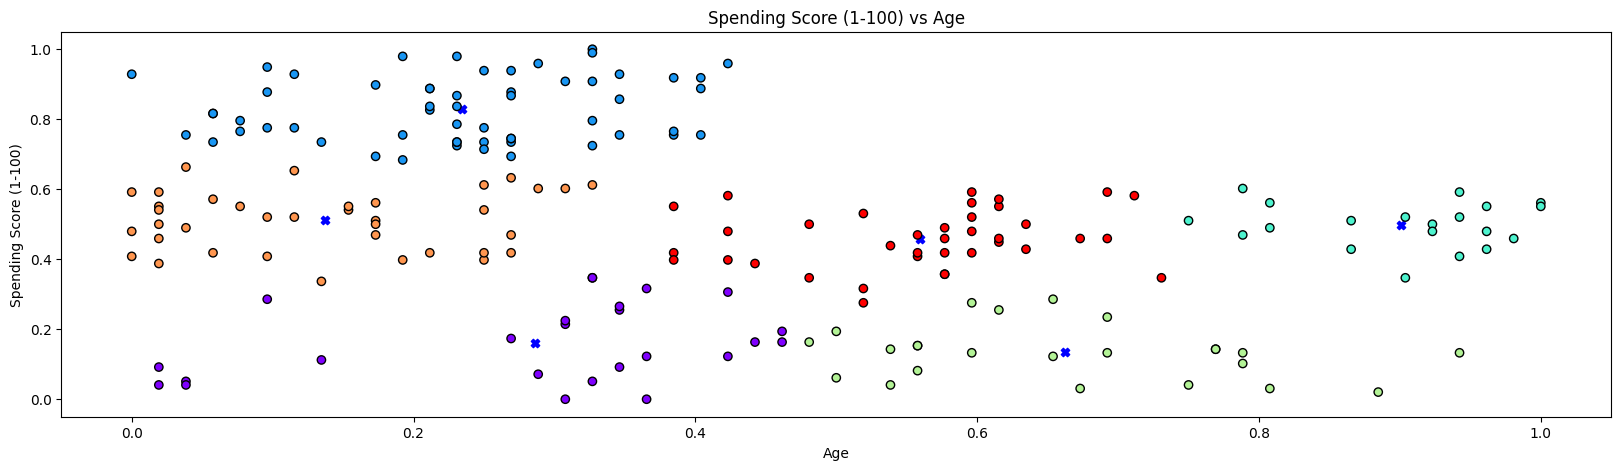

In [317]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();


### Annual Income (k$) - Spending Score (1-100)

In [318]:
m1 = df1[['Annual Income (k$)', 'Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Annual Income (k$)', 'Spending Score (1-100)']].values # Normalized Dataset

### Original Dataset :
**Elbow Method & Silhouette Score Method :**

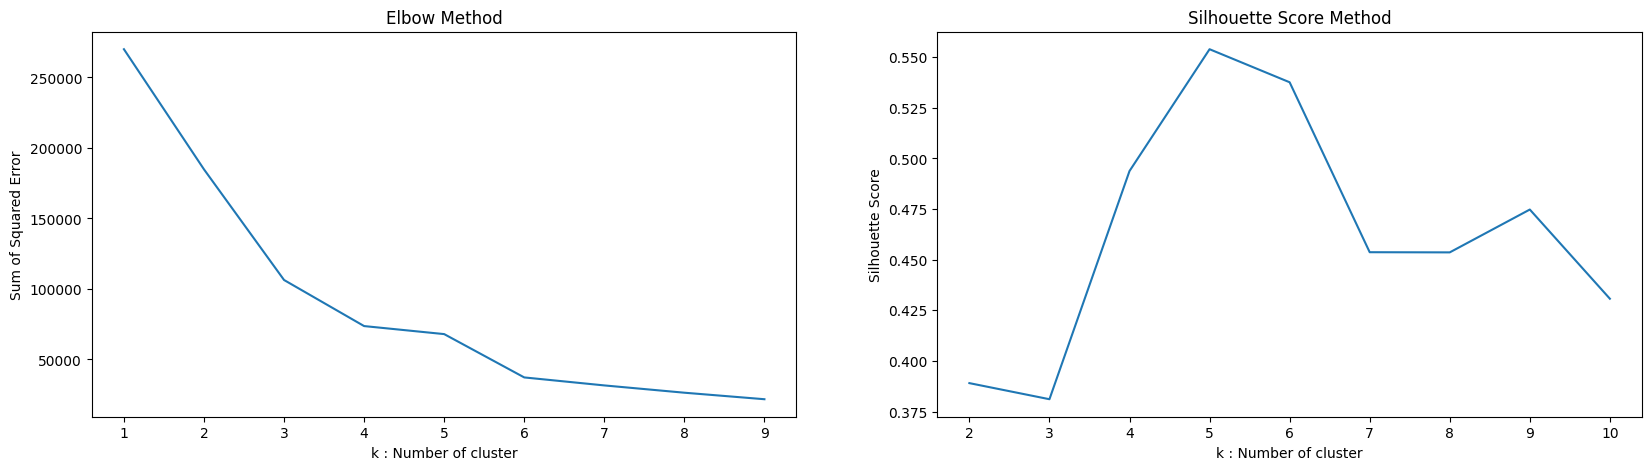

In [319]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- k : Clusters = 5

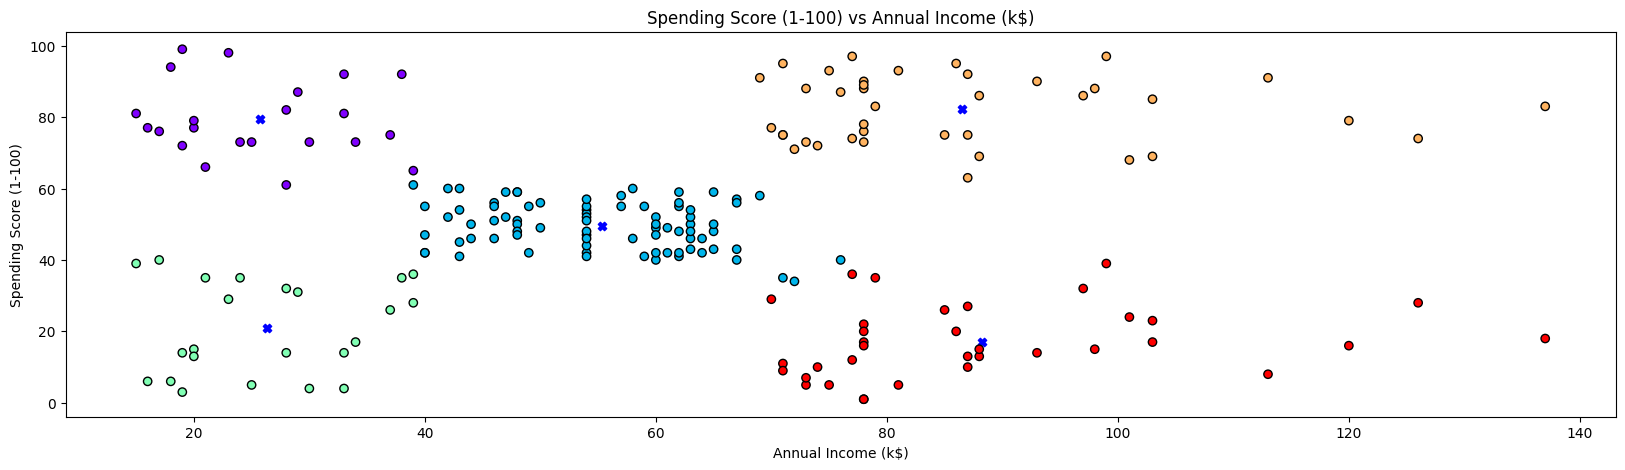

In [320]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Normalized Dataset :
**Elbow Method & Silhouette Score Method :**

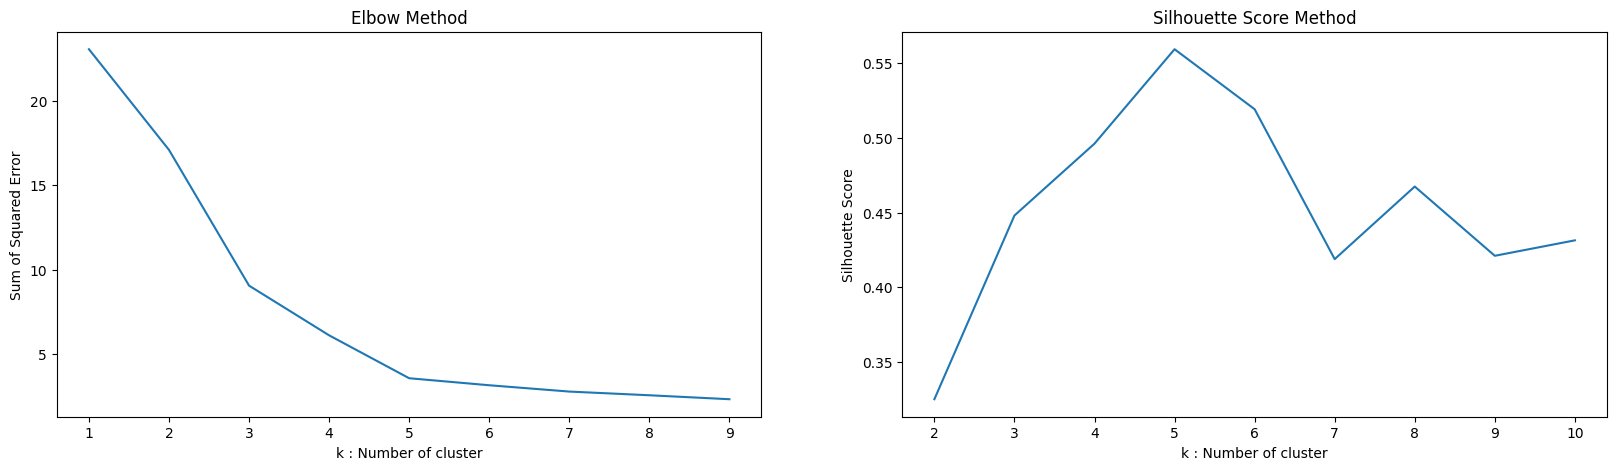

In [321]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- k : Clusters = 5

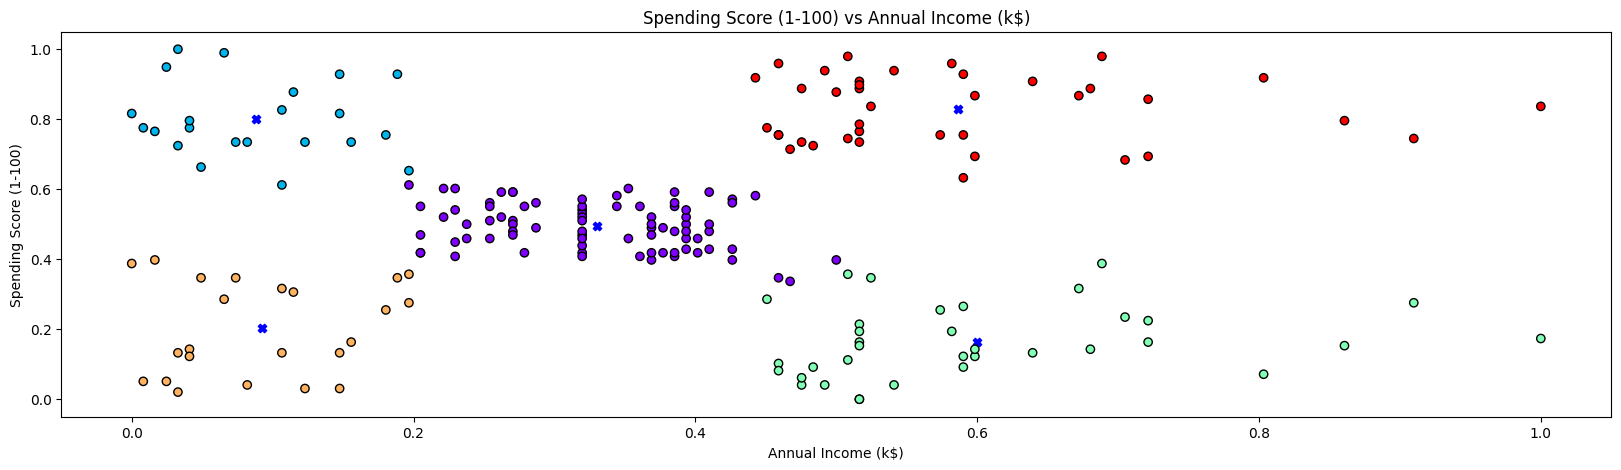

In [322]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Age - Annual Income (k$) - Spending Score (1-100)

In [323]:
m1 = df1[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Normalized Dataset

### Original Dataset :
**Elbow Method & Silhouette Score Method :**

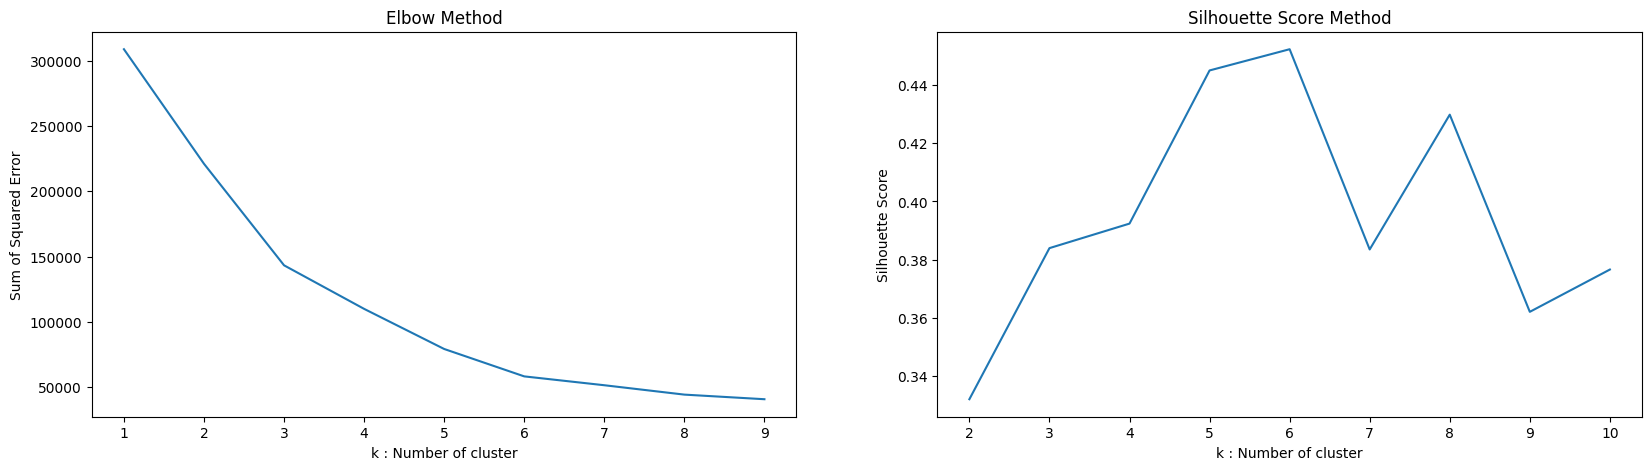

In [324]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- k : Clusters = 6

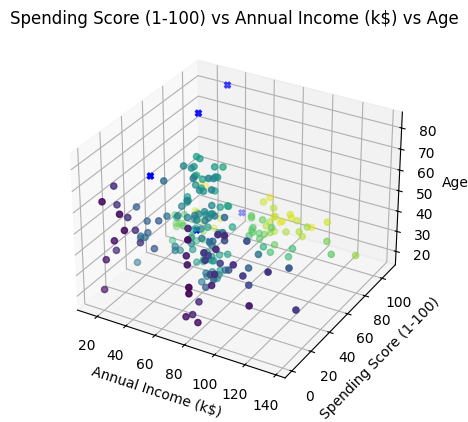

In [325]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') ## 수정
x = np.array(df1['Annual Income (k$)'])
y = np.array(df1['Spending Score (1-100)'])
z = np.array(df1['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],marker="X", color = 'b')
ax.scatter(x,y,z,c = y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

### Normalized Dataset
**Elbow Method & Silhouette Score Method :**

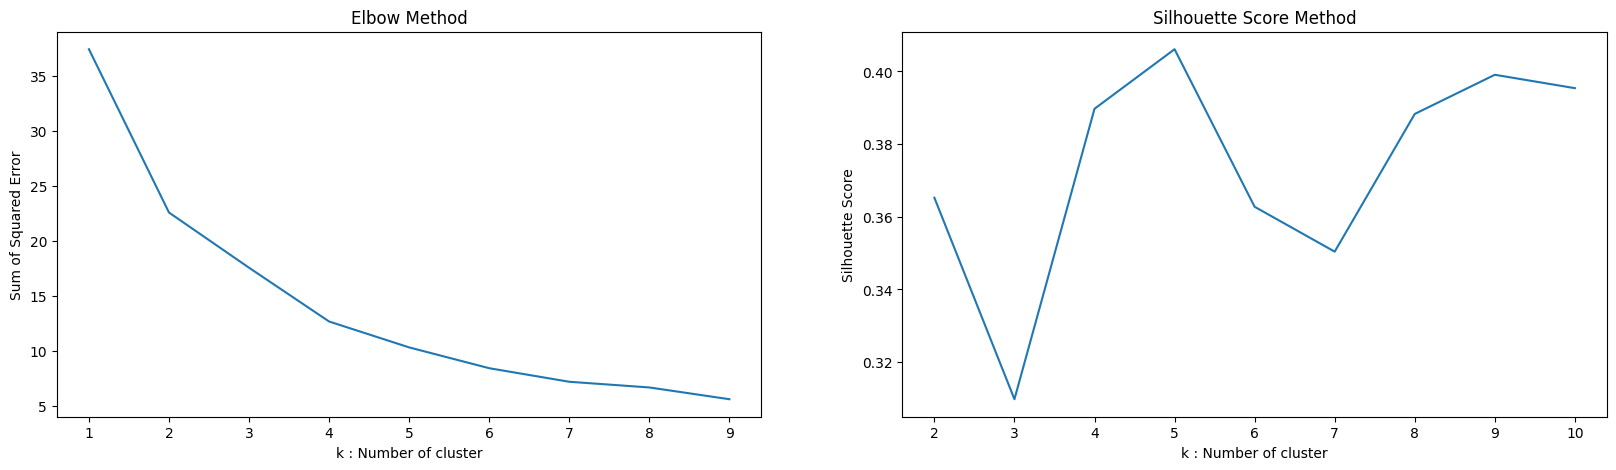

In [326]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- k : Clusters = 6

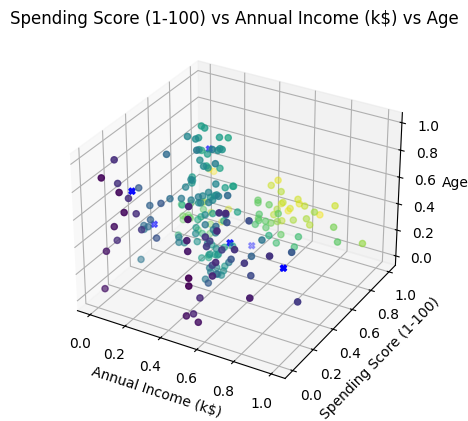

In [327]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') ## 수정
x = np.array(df2['Annual Income (k$)'])
y = np.array(df2['Spending Score (1-100)'])
z = np.array(df2['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],marker = "X", color = 'b')
ax.scatter(x,y,z,c = y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

# Conclusion

- 본 데이터셋은 비지도 학습(Unsupervised Learning) 문제를 다루는 방법을 이해하는 데 매우 유용함. 매출을 증대시키기 위한 다양한 비즈니스 전략을 수립하고 실무에 적용해 볼 수 있는 좋은 기회를 제공한다.

EDA
- 비지도 학습 문제에서는 데이터에 숨겨진 통찰(Insight)을 발굴하는 데 EDA가 매우 중요. 다만, 특성(Feature)의 수가 늘어나고 데이터의 규모가 커질수록 시각화의 복잡도가 증가하여 분석이 어려울 수 있다.

K-Means 클러스터링
- K-Means 알고리즘에서 하이퍼파라미터 k(클러스터 개수) 선택은 핵심이며 이를 위해 Elbow Method와 Silhouette Score 같은 기법을 사용
- 본 케이스의 경우, 원본 데이터셋으로 학습했을 때와 정규화(Normalization)된 데이터셋으로 학습했을 때의 모델 성능 차이가 그리 크지 않은 것으로 나타남.